In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from core.data_handler import DataHandler

In [4]:
aapl_handler = DataHandler('AAPL', period = '2y', interval='1h')
msft_handler = DataHandler('MSFT', period = '2y', interval='1h')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
aapl_handler.df.columns

Index(['Datetime', 'Close', 'High', 'Low', 'Open', 'Volume', 'Date', 'Hour',
       'DayOpen', 'LogDayOpen', 'EODClose', 'LogEODClose', 'PrevEODClose',
       'LogPrevEODClose', 'Label', 'SimpleReturn', 'SMA_20', 'SMA_50', 'RSI',
       'Volatility', 'LogClose', 'LogReturn', 'RangePct', 'CloseOpenPct',
       'RetLag1', 'RetLag2', 'RetLag3', 'RetLag5', 'RetLag10', 'RetLag21',
       'RollMeanRet5', 'RollStdRet5', 'PriceMom5', 'RollMeanRet10',
       'RollStdRet10', 'PriceMom10', 'RollMeanRet21', 'RollStdRet21',
       'PriceMom21', 'RollMeanRet63', 'RollStdRet63', 'PriceMom63', 'EMA12',
       'EMA26', 'MACD', 'MACDSignal', 'RSI14', 'ATR14', 'ATR14Pct',
       'DayOfWeek', 'Month', 'HourSin', 'HourCos', 'DoWSin', 'DoWCos',
       'MonthSin', 'MonthCos', 'SentimentMean', 'SentimentWeighted',
       'SentimentRolling5', 'SentimentDelta', 'ArticleCount'],
      dtype='object')

<Axes: xlabel='Datetime', ylabel='Closing Price'>

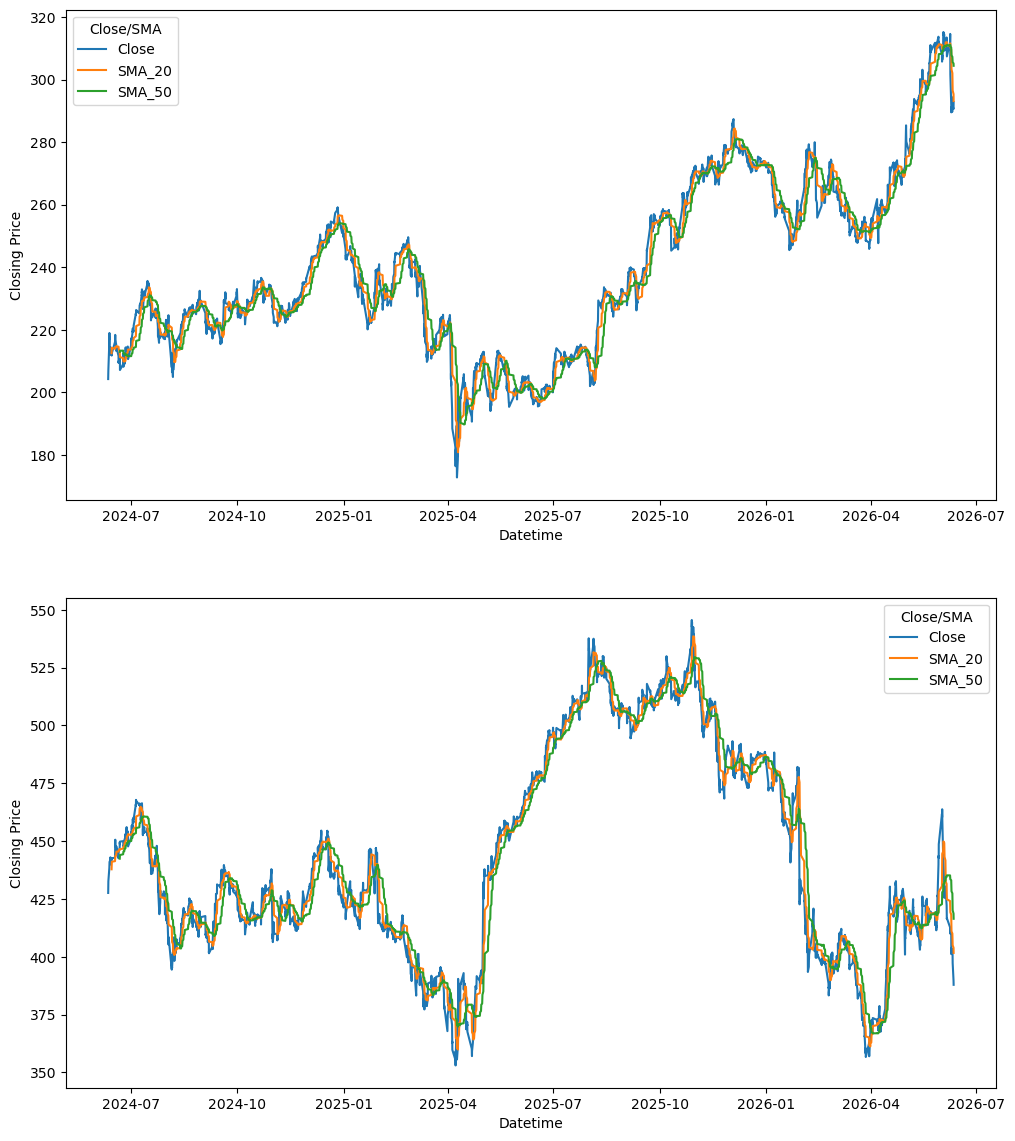

In [5]:
fig, ax = plt.subplots(2, figsize = (12, 14))

sns.lineplot(data=aapl_handler.df.melt(
    id_vars = "Datetime",
    value_vars = ["Close", "SMA_20", "SMA_50"],
    value_name = "Closing Price",
    var_name = "Close/SMA"
), x = "Datetime", y="Closing Price", hue = "Close/SMA", ax=ax[0])

sns.lineplot(data=msft_handler.df.melt(
    id_vars = "Datetime",
    value_vars = ["Close", "SMA_20", "SMA_50"],
    value_name = "Closing Price",
    var_name = "Close/SMA"
), x = "Datetime", y="Closing Price", hue = "Close/SMA", ax=ax[1])


Need to do analysis on:
* Threshold to use
* Stop loss and take profit to use

## How to calculate stop loss and take profit
* Calculate decimal up move and down move
* Calculate close move, the decimal if no stop loss or take profit is hit

In [7]:
def analyse_stop_take(df, thresholds):

    df['UpMove'] = (df['High'] - df['Open']) / df['Open']
    df['DownMove'] = (df['Open'] - df['Low']) / df['Open']
    df['CloseMove'] = (df['Close'] - df['Open']) / df['Open']

    results = []
    for stop in thresholds:
        for take in thresholds:
            if take <= stop:
                continue  # Take profit must be bigger than stop loss

            wins, losses, neutral = 0, 0, 0
            returns = []

            for _, row in df.iterrows():
                up_move   = row['UpMove']
                down_move = row['DownMove']
                close_move = row['CloseMove']

                # Simulate a long trade
                if down_move >= stop:
                    # Stop loss hit
                    returns.append(-stop)
                    losses += 1
                elif up_move >= take:
                    # Take profit hit
                    returns.append(take)
                    wins += 1
                else:
                    # Neither hit — close at EOD
                    returns.append(close_move)
                    neutral += 1

            total_return = pd.Series(returns).add(1).cumprod().iloc[-1] - 1
            results.append({
                'stop_loss'   : stop,
                'take_profit' : take,
                'total_return': total_return,
                'wins'        : wins,
                'losses'      : losses,
                'neutral'     : neutral,
                'risk_reward' : take / stop
            })

    results_df = pd.DataFrame(results).sort_values('total_return', ascending=False)
    #print(results_df.head(10).to_string(index=False))
    return results_df

thresholds = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.04, 0.05]

aapl_day_handler = DataHandler('AAPL', period = '4y', interval='1d')
msft_day_handler = DataHandler('MSFT', period = '4y', interval='1d')

for handler in [aapl_day_handler, msft_day_handler]:
    display(analyse_stop_take(handler.df, thresholds).head(10))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,stop_loss,take_profit,total_return,wins,losses,neutral,risk_reward
21,0.020,0.050,2.023221,10,110,883,2.500000
26,0.030,0.050,1.814126,10,35,958,1.666667
20,0.020,0.040,1.802925,16,110,877,2.000000
17,0.015,0.050,1.748768,9,200,794,3.333333
27,0.040,0.050,1.692819,10,14,979,1.250000
24,0.025,0.050,1.686941,10,66,927,2.000000
25,0.030,0.040,1.609066,16,35,952,1.333333
16,0.015,0.040,1.572975,15,200,788,2.666667
19,0.020,0.030,1.563295,39,110,854,1.500000
18,0.020,0.025,1.549270,68,110,825,1.250000


,stop_loss,take_profit,total_return,wins,losses,neutral,risk_reward
21,0.020,0.050,0.425698,5,111,887,2.500000
20,0.020,0.040,0.391518,11,111,881,2.000000
12,0.010,0.050,0.367265,3,387,613,5.000000
11,0.010,0.040,0.360272,9,387,607,4.000000
19,0.020,0.030,0.319063,28,111,864,1.500000
18,0.020,0.025,0.315082,51,111,841,1.250000
10,0.010,0.030,0.309681,25,387,591,3.000000
9,0.010,0.025,0.270099,46,387,570,2.500000
8,0.010,0.020,0.203924,88,387,528,2.000000
17,0.015,0.050,0.199266,4,216,783,3.333333


Best stop losses and take profits for AAPL and MSFT:  
0.02 and 0.05   
For BTC:  
0.015 and 0.04  

In [6]:
import matplotlib.pyplot as plt

def gradient_importance(model, X_test, feature_cols):
    model.eval()
    
    X = X_test.clone().requires_grad_(True)
    
    output = model(X).squeeze()
    output.sum().backward()  # Backprop through the whole test set
    
    # Average absolute gradient across samples and timesteps
    # Shape: (samples, timesteps, features) → average to (features,)
    grads = X.grad.abs().mean(dim=(0, 1)).numpy()
    
    # Normalise to percentage
    grads = grads / grads.sum() * 100

    # Plot
    plt.figure(figsize=(10, 5))
    sorted_idx = np.argsort(grads)[::-1]
    plt.bar(
        [feature_cols[i] for i in sorted_idx],
        [grads[i] for i in sorted_idx],
        color='steelblue'
    )
    plt.title("Gradient-Based Feature Importance")
    plt.ylabel("Importance (%)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    for i in sorted_idx:
        print(f"{feature_cols[i]}: {grads[i]:.2f}%")

    return grads

In [7]:
from core.data_handler import DataHandler
from core.trading_lstm import TradingLTSM
from sklearn.model_selection import train_test_split
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib

def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        preds = model(X_test).squeeze()
        pred_labels = (preds > 0.5).float()  # Convert probabilities to 0/1
    
    # Accuracy
    accuracy = (pred_labels == y_test.squeeze()).float().mean().item()
    print(f"Accuracy: {accuracy:.2%}")
    
    return preds, pred_labels


def gradient_importance(model, X_test, feature_cols):
    model.eval()
    
    X = X_test.clone().requires_grad_(True)
    
    output = model(X).squeeze()
    output.sum().backward()  # Backprop through the whole test set
    
    # Average absolute gradient across samples and timesteps
    # Shape: (samples, timesteps, features) → average to (features,)
    grads = X.grad.abs().mean(dim=(0, 1)).numpy()
    
    # Normalise to percentage
    grads = grads / grads.sum() * 100

    # Plot
    plt.figure(figsize=(10, 5))
    sorted_idx = np.argsort(grads)[::-1]
    plt.bar(
        [feature_cols[i] for i in sorted_idx],
        [grads[i] for i in sorted_idx],
        color='steelblue'
    )
    plt.title("Gradient-Based Feature Importance")
    plt.ylabel("Importance (%)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # for i in sorted_idx:
    #     print(f"{feature_cols[i]}: {grads[i]:.2f}%")

    return grads


def feature_label_correlation(df, feature_cols, label_col='Label'):
    correlations = {}

    for feature in feature_cols:
        corr = df[feature].corr(df[label_col])
        correlations[feature] = corr

    sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

    plt.figure(figsize=(10, 5))
    features, corrs = zip(*sorted_corr)
    colors = ['green' if c > 0 else 'red' for c in corrs]
    plt.bar(features, corrs, color=colors)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title("Feature Correlation With Label")
    plt.ylabel("Correlation")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # for f, c in sorted_corr:
    #     print(f"{f}: {c:+.4f}")


def find_optimal_threshold(model, X_test, y_test, df, dates_test):
    model.eval()
    with torch.no_grad():
        preds = model(X_test).squeeze().numpy()
    
    y_true = y_test.squeeze().numpy()
    prices = df['EODClose'].values

    daily = df.groupby('Date').agg(
        DayOpen = ('Open', 'first'),
        EODClose = ('Close', 'last')
    )
    daily['actual_return'] = (daily['EODClose'] - daily['DayOpen']) / daily['DayOpen']
    actual_returns = np.array([daily.loc[date, 'actual_return'] for date in dates_test])

    # Sanity check — these must match
    print(f"Predictions:     {len(preds)}")
    print(f"Actual returns:  {len(actual_returns)}")
    print(f"Test dates:      {len(dates_test)}")
    assert len(preds) == len(actual_returns) == len(dates_test), \
        "Mismatch between predictions, returns and dates — check your splits"

    thresholds = np.arange(0.5, 0.95, 0.05)
    results = []

    for threshold in thresholds:
        trades      = 0
        correct     = 0
        strategy    = []

        for i in range(len(preds) - 1):
            day_return = actual_returns[i]

            if preds[i] > threshold:
                trades += 1
                correct += 1 if y_true[i] == 1 else 0
                strategy.append(day_return)

            elif preds[i] < (1 - threshold):
                trades += 1
                correct += 1 if y_true[i] == 0 else 0
                strategy.append(-day_return)

            else:
                strategy.append(0)  # Sitting out

        accuracy      = correct / trades if trades > 0 else 0
        total_return  = pd.Series(strategy).add(1).cumprod().iloc[-1] - 1
        trade_pct     = trades / len(preds) * 100

        results.append({
            'threshold'   : round(threshold, 2),
            'accuracy'    : accuracy,
            'total_return': total_return,
            'trades'      : trades,
            'trade_pct'   : trade_pct
        })

        print(f"Threshold {threshold:.2f} | "
              f"Accuracy: {accuracy:.2%} | "
              f"Return: {total_return:+.2%} | "
              f"Trades: {trades} ({trade_pct:.0f}% of days)")

    results_df = pd.DataFrame(results)
    _plot_threshold_results(results_df)
    return results_df

def _plot_threshold_results(results_df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(results_df['threshold'], results_df['accuracy'], marker='o', color='blue')
    axes[0].axhline(0.5, color='red', linestyle='--', label='Random baseline')
    axes[0].set_title('Accuracy vs Threshold')
    axes[0].set_xlabel('Threshold')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(results_df['threshold'], results_df['total_return'] * 100, marker='o', color='green')
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title('Total Return vs Threshold')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('Return (%)')

    axes[2].bar(results_df['threshold'], results_df['trade_pct'], color='orange', width=0.03)
    axes[2].set_title('% of Days Traded vs Threshold')
    axes[2].set_xlabel('Threshold')
    axes[2].set_ylabel('% Days Traded')

    plt.tight_layout()
    plt.show()



[*********************100%***********************]  1 of 1 completed


Input size: 58
['Close', 'High', 'Low', 'Open', 'Volume', 'DayOpen', 'LogDayOpen', 'EODClose', 'LogEODClose', 'PrevEODClose', 'LogPrevEODClose', 'SimpleReturn', 'SMA_20', 'SMA_50', 'RSI', 'Volatility', 'LogClose', 'LogReturn', 'RangePct', 'CloseOpenPct', 'RetLag1', 'RetLag2', 'RetLag3', 'RetLag5', 'RetLag10', 'RetLag21', 'RollMeanRet5', 'RollStdRet5', 'PriceMom5', 'RollMeanRet10', 'RollStdRet10', 'PriceMom10', 'RollMeanRet21', 'RollStdRet21', 'PriceMom21', 'RollMeanRet63', 'RollStdRet63', 'PriceMom63', 'EMA12', 'EMA26', 'MACD', 'MACDSignal', 'RSI14', 'ATR14', 'ATR14Pct', 'DayOfWeek', 'Month', 'HourSin', 'HourCos', 'DoWSin', 'DoWCos', 'MonthSin', 'MonthCos', 'SentimentMean', 'SentimentWeighted', 'SentimentRolling5', 'SentimentDelta', 'ArticleCount']
Epoch 0 | Loss: 0.6901
Epoch 10 | Loss: 0.6874
Epoch 20 | Loss: 0.6760
Epoch 30 | Loss: 0.6279
Epoch 40 | Loss: 0.5422
Accuracy: 57.73%


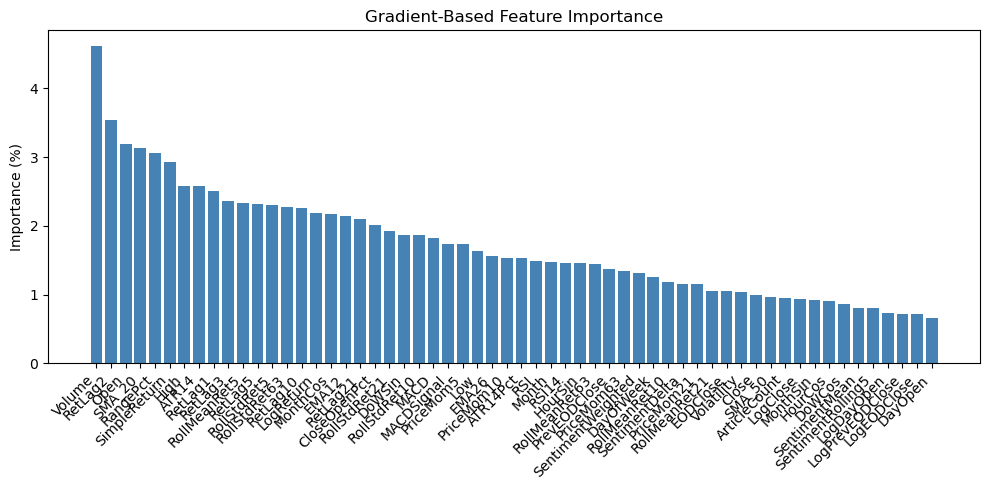

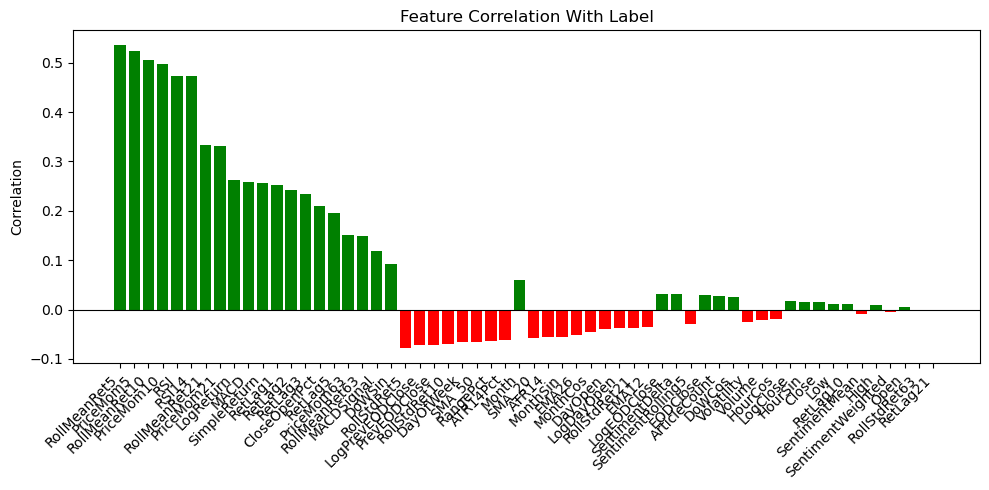

Predictions:     97
Actual returns:  97
Test dates:      97
Threshold 0.50 | Accuracy: 58.33% | Return: +18.40% | Trades: 96 (99% of days)
Threshold 0.55 | Accuracy: 58.51% | Return: +18.34% | Trades: 94 (97% of days)
Threshold 0.60 | Accuracy: 58.82% | Return: +26.17% | Trades: 85 (88% of days)
Threshold 0.65 | Accuracy: 58.67% | Return: +16.08% | Trades: 75 (77% of days)
Threshold 0.70 | Accuracy: 60.00% | Return: +16.76% | Trades: 70 (72% of days)
Threshold 0.75 | Accuracy: 61.40% | Return: +18.83% | Trades: 57 (59% of days)
Threshold 0.80 | Accuracy: 62.50% | Return: +20.28% | Trades: 48 (49% of days)
Threshold 0.85 | Accuracy: 56.25% | Return: +4.99% | Trades: 32 (33% of days)
Threshold 0.90 | Accuracy: 56.52% | Return: +2.50% | Trades: 23 (24% of days)


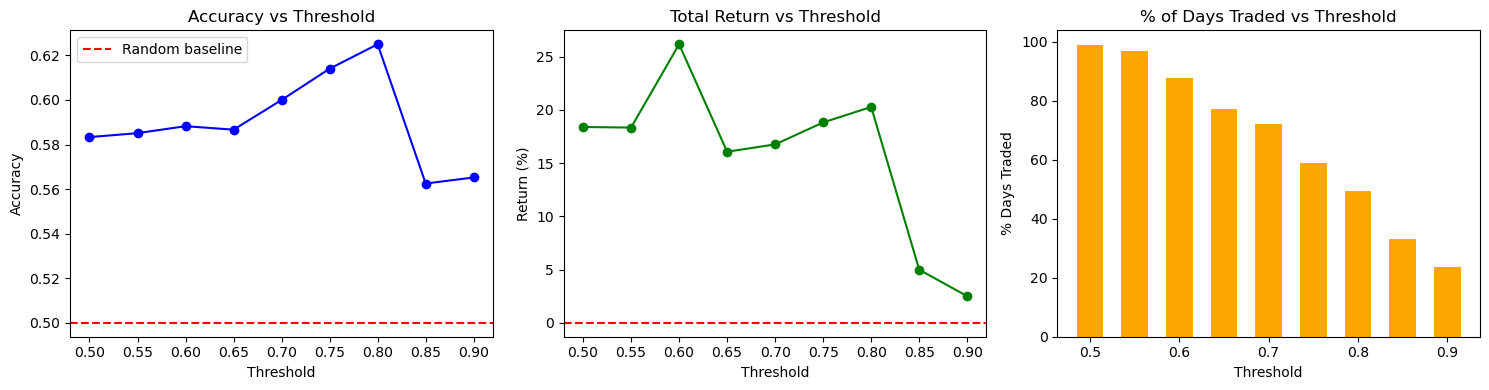

['models/aapl_scaler1.pkl']

In [11]:
def train_test_model(ticker, remove, hidden_size, num_layers, dropout, epochs):
    
    data_handler = DataHandler(ticker, period="2y")
    df = data_handler.df
    df.dropna(inplace = True)
    columns = df.columns.tolist()

    features = [col for col in columns if col not in remove]
    trading_ltsm = TradingLTSM(hidden_size=hidden_size, num_layers=num_layers, feature_cols=features, dropout=dropout)
    X, y, dates, scaler = trading_ltsm.prepare_daily_sequences(df)

    print(features)

    split = int(len(X) * 0.8)
    #dates = df['Date'].unique()

    # X_train = X[:split]
    # X_test  = X[split:]
    # y_train = y[:split]
    # y_test  = y[split:]
    # dates_train = dates[:split]
    # dates_test  = dates[split:]

    X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(X, y, dates, train_size=0.8)

    trading_ltsm.train_model(X_train, y_train, epochs=epochs)

    evaluate_model(trading_ltsm, X_test, y_test)

    gradient_importance(trading_ltsm, X_test, features)

    feature_label_correlation(df, features)

    find_optimal_threshold(trading_ltsm, X_test, y_test, df, dates_test)

    return trading_ltsm, scaler

remove = ["Datetime", "Date", "Hour", "Label"]
ticker = 'AAPL'
hidden_size=64
num_layers=3
dropout=0.15
epochs=50

aapl_model, aapl_scaler = train_test_model(ticker, remove, hidden_size, num_layers, dropout, epochs)

torch.save(aapl_model.state_dict(), 'models/aapl_model1.pth')
joblib.dump(aapl_scaler, 'models/aapl_scaler1.pkl')



[*********************100%***********************]  1 of 1 completed


Input size: 58
['Close', 'High', 'Low', 'Open', 'Volume', 'DayOpen', 'LogDayOpen', 'EODClose', 'LogEODClose', 'PrevEODClose', 'LogPrevEODClose', 'SimpleReturn', 'SMA_20', 'SMA_50', 'RSI', 'Volatility', 'LogClose', 'LogReturn', 'RangePct', 'CloseOpenPct', 'RetLag1', 'RetLag2', 'RetLag3', 'RetLag5', 'RetLag10', 'RetLag21', 'RollMeanRet5', 'RollStdRet5', 'PriceMom5', 'RollMeanRet10', 'RollStdRet10', 'PriceMom10', 'RollMeanRet21', 'RollStdRet21', 'PriceMom21', 'RollMeanRet63', 'RollStdRet63', 'PriceMom63', 'EMA12', 'EMA26', 'MACD', 'MACDSignal', 'RSI14', 'ATR14', 'ATR14Pct', 'DayOfWeek', 'Month', 'HourSin', 'HourCos', 'DoWSin', 'DoWCos', 'MonthSin', 'MonthCos', 'SentimentMean', 'SentimentWeighted', 'SentimentRolling5', 'SentimentDelta', 'ArticleCount']
Epoch 0 | Loss: 0.6940
Epoch 10 | Loss: 0.6910
Epoch 20 | Loss: 0.6834
Epoch 30 | Loss: 0.6477
Epoch 40 | Loss: 0.5404
Epoch 50 | Loss: 0.4041
Accuracy: 52.58%


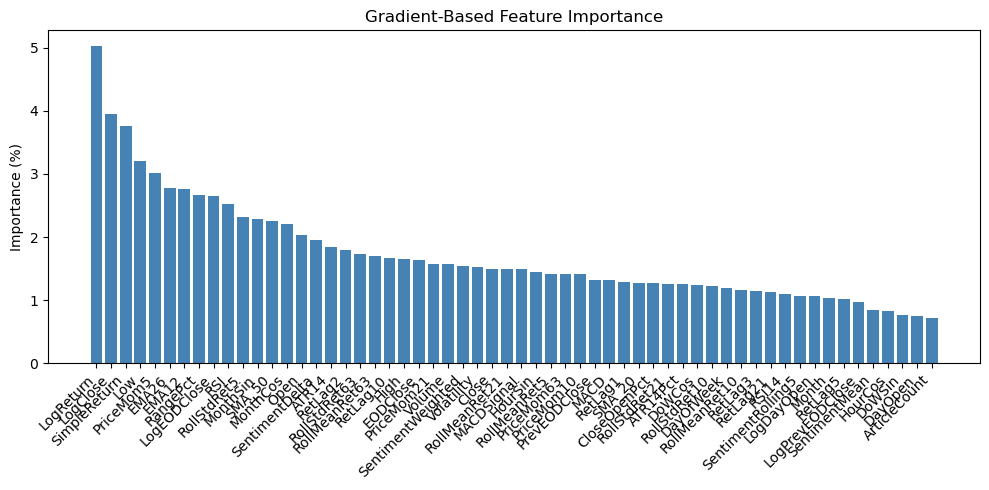

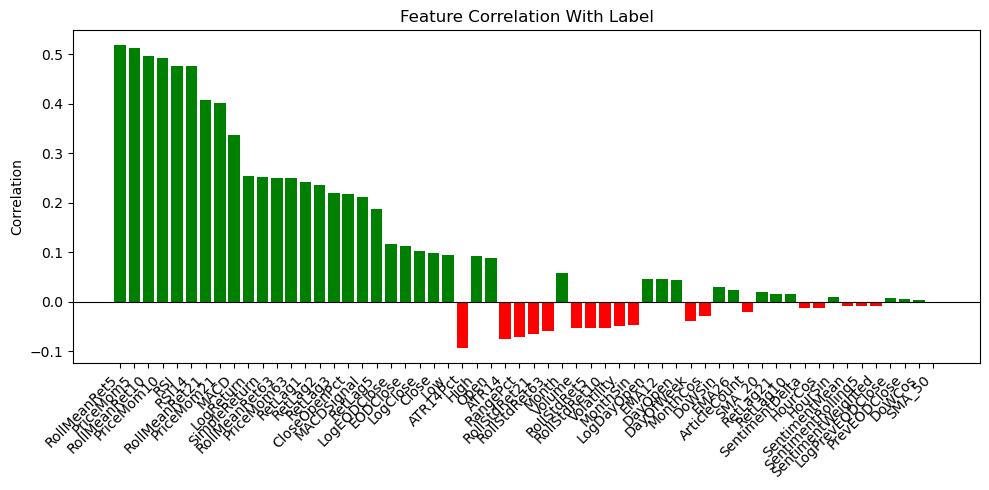

Predictions:     97
Actual returns:  97
Test dates:      97
Threshold 0.50 | Accuracy: 52.08% | Return: +13.76% | Trades: 96 (99% of days)
Threshold 0.55 | Accuracy: 52.17% | Return: +13.68% | Trades: 92 (95% of days)
Threshold 0.60 | Accuracy: 52.87% | Return: +12.27% | Trades: 87 (90% of days)
Threshold 0.65 | Accuracy: 53.49% | Return: +11.60% | Trades: 86 (89% of days)
Threshold 0.70 | Accuracy: 53.57% | Return: +12.75% | Trades: 84 (87% of days)
Threshold 0.75 | Accuracy: 55.26% | Return: +11.56% | Trades: 76 (78% of days)
Threshold 0.80 | Accuracy: 54.55% | Return: +5.75% | Trades: 66 (68% of days)
Threshold 0.85 | Accuracy: 56.90% | Return: +10.60% | Trades: 58 (60% of days)
Threshold 0.90 | Accuracy: 50.00% | Return: +3.77% | Trades: 44 (45% of days)


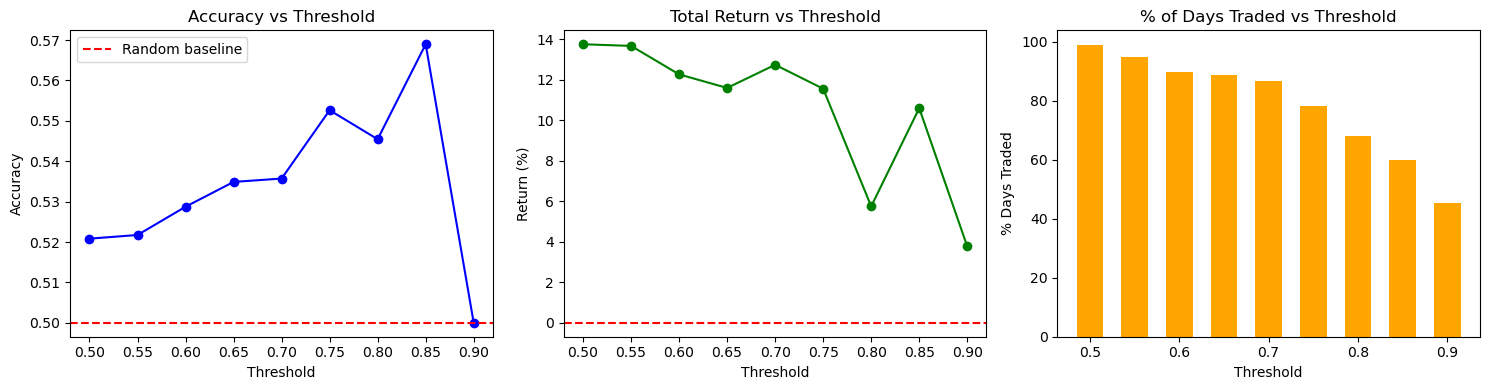

['models/msft_scaler1.pkl']

In [18]:
remove = ["Datetime", "Date", "Hour", "Label"]
ticker = 'MSFT'
hidden_size=64
num_layers=3
dropout=0.15
epochs=60

msft_model, msft_scaler = train_test_model(ticker, remove, hidden_size, num_layers, dropout, epochs)

torch.save(msft_model.state_dict(), 'models/msft_model1.pth')
joblib.dump(msft_scaler, 'models/msft_scaler1.pkl')

In [2]:

import torch
import joblib
import plotly.graph_objects as go
from alpaca.broker import BrokerClient
from core.data_handler import DataHandler
from core.paper_trader import PaperTrader
from core.trading_lstm import TradingLTSM
from core.constants import *


def load_model_and_scaler(ticker):
    model = TradingLTSM(
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        feature_cols=FEATURES
    )

    ticker = ticker.lower()

    model.load_state_dict(torch.load(f'models/{ticker}_model.pth', map_location='cpu'))
    model.eval()

    scaler = joblib.load(f'models/{ticker}_scaler.pkl')
    print("Model and scaler loaded")
    return model, scaler

def load_papertrader(_model, ticker):
    return PaperTrader(_model, ticker, cash_fraction=CASH_FRACTION, threshold=THRESHOLD)

tickers = ['AAPL', 'MSFT']
models = {}
scalers = {}
traders = {}
for ticker in tickers:
    models[ticker], scalers[ticker] =  load_model_and_scaler(ticker)
    traders[ticker] = load_papertrader(models[ticker], ticker)

trading_client = list(traders.values())[0].trading_client

def get_prediction_now(ticker):
    try:
        pred, date_used = models[ticker].get_yesterdays_prediction(
            ticker,
            scalers[ticker]
        )
        return pred, date_used, None
    except Exception as e:
        return None, None, str(e)
    
pred, date_used, error = get_prediction_now('AAPL')

print(pred, date_used)

pred, date_used, error = get_prediction_now('MSFT')

print(pred, date_used)

Input size: 53
Model and scaler loaded
Cash: $100134.58
Portfolio Value: $100134.58
Input size: 53
Model and scaler loaded


[*********************100%***********************]  1 of 1 completed

Cash: $100134.58
Portfolio Value: $100134.58
0.27725526690483093 2026-03-17



[*********************100%***********************]  1 of 1 completed

0.32457423210144043 2026-03-17


In [6]:
data_handler = DataHandler('AAPL', period="14d", interval="1h")
df = data_handler.df

available_dates = sorted(df["Date"].unique())

if len(available_dates) < 2:
    raise ValueError("Not enough data — need at least 2 days")

yesterday = available_dates[-2]
yesterday_df = df[df["Date"] == yesterday].sort_values("Datetime")
df.tail()

[*********************100%***********************]  1 of 1 completed


,Datetime,Close,High,Low,Open,Volume,Date,Hour,DayOpen,LogDayOpen,...,ATR14,ATR14Pct,DayOfWeek,Month,HourSin,HourCos,DoWSin,DoWCos,MonthSin,MonthCos
93,2026-03-17 15:30:00+00:00,254.860001,255.129898,253.660004,254.149994,1738870,2026-03-17,15,253.078506,5.5337,...,1.521582,0.005970,1,3,-0.707107,-7.071068e-01,0.951057,0.309017,1.0,6.123234e-17
94,2026-03-17 16:30:00+00:00,253.919998,255.029999,253.559998,254.869995,6074290,2026-03-17,16,253.078506,5.5337,...,1.483012,0.005840,1,3,-0.866025,-5.000000e-01,0.951057,0.309017,1.0,6.123234e-17
95,2026-03-17 17:30:00+00:00,254.100006,254.630005,253.884995,253.910004,0,2026-03-17,17,253.078506,5.5337,...,1.473498,0.005799,1,3,-0.965926,-2.588190e-01,0.951057,0.309017,1.0,6.123234e-17
96,2026-03-17 18:30:00+00:00,253.770004,254.330002,253.130096,254.095001,1332707,2026-03-17,18,253.078506,5.5337,...,1.442420,0.005684,1,3,-1.000000,-1.836970e-16,0.951057,0.309017,1.0,6.123234e-17
97,2026-03-17 19:30:00+00:00,254.229996,254.580002,253.679993,253.779999,1930468,2026-03-17,19,253.078506,5.5337,...,1.428135,0.005617,1,3,-0.965926,2.588190e-01,0.951057,0.309017,1.0,6.123234e-17
